# 50.007 Machine Learning Project — GenAI Content Detection

Binary classification of text as **machine-generated (1)** or **human-authored (0)**.
Evaluation metric: **Macro F1**.

- **Task 1** — Logistic Regression implemented from scratch (NumPy only)
- **Task 2** — PCA dimensionality reduction + KNN (n_neighbors=2)
- **Task 3** — Model race: multiple ML models with hyperparameter tuning


In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score

SEED = 42
rng = np.random.default_rng(SEED)

DATA_DIR = Path("data")
PRED_DIR = Path("predictions")
PRED_DIR.mkdir(exist_ok=True)

## Data loading

The competition provides:

| file | contents |
|---|---|
| `train_features.csv` | 20,000 rows × (`id`, `label`, 5000 TF-IDF features) |
| `test_features.csv`  | 6,999 rows × (`id`, 5000 TF-IDF features) |
| `train.csv` / `test.csv` | the same ids with the **raw text** |

There is no separate labelled dev set, so we hold out a stratified 10% of train as our
validation set for model comparison. Features are loaded as `float32` to halve memory
(the TF-IDF values are in [0, 1]).

In [2]:
train_feat = pd.read_csv(DATA_DIR / "train_features.csv")
test_feat = pd.read_csv(DATA_DIR / "test_features.csv")
train_text = pd.read_csv(DATA_DIR / "train.csv")   # id, text, label
test_text = pd.read_csv(DATA_DIR / "test.csv")     # id, text

feature_cols = [c for c in train_feat.columns if c not in ("id", "label")]
X_train = train_feat[feature_cols].to_numpy(dtype=np.float32)
y_train = train_feat["label"].to_numpy(dtype=int)
X_test = test_feat[feature_cols].to_numpy(dtype=np.float32)
test_ids = test_feat["id"].to_numpy()

assert (train_feat["id"].values == train_text["id"].values).all()
assert (test_feat["id"].values == test_text["id"].values).all()

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("class balance (0=human, 1=machine):", np.bincount(y_train))

X_train: (20000, 5000) | X_test: (6999, 5000)
class balance (0=human, 1=machine): [ 7496 12504]


In [3]:
from sklearn.model_selection import train_test_split

tr_idx, val_idx = train_test_split(np.arange(len(y_train)), test_size=0.1,
                                   stratify=y_train, random_state=SEED)
X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
X_val, y_val = X_train[val_idx], y_train[val_idx]
print(f"train split: {len(y_tr)} | validation split: {len(y_val)}")

train split: 18000 | validation split: 2000


In [4]:
def save_predictions(ids, labels, path):
    """Write a Kaggle submission file: header id,label with labels in {0,1}."""
    out = pd.DataFrame({"id": ids, "label": np.asarray(labels, dtype=int)})
    out.to_csv(path, index=False)
    print(f"saved {path} ({len(out)} rows, positives={out['label'].sum()})")

def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")

## Task 1 — Logistic Regression from scratch

Implemented with NumPy only (no sklearn LogisticRegression). The model is
$\hat{y} = \sigma(Xw + b)$ trained by minimising the **log loss**

$$L = -\frac{1}{m}\sum_i \left[ y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \right]$$

with mini-batch gradient descent. Gradients: $\partial L/\partial w = \frac{1}{m}X^T(\hat{y}-y)$,
$\partial L/\partial b = \frac{1}{m}\sum_i(\hat{y}_i - y_i)$.

In [5]:
def sigmoid(z):
    """Map any real input to (0, 1). Clipped for numerical stability so
    np.exp never overflows."""
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def loss(y, y_hat):
    """Log loss (binary cross-entropy) between actual labels y and predicted
    probabilities y_hat. y_hat is clipped away from 0/1 to avoid log(0)."""
    eps = 1e-9
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return float(-np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)))


def gradients(X, y, y_hat):
    """Partial derivatives of the log loss w.r.t. weights (dw) and bias (db)."""
    m = X.shape[0]
    dw = X.T @ (y_hat - y) / m
    db = np.mean(y_hat - y)
    return dw, db

In [6]:
def train(X, y, bs, epochs, lr):
    """Mini-batch gradient descent.

    X: (m, n) features, y: (m,) labels in {0,1},
    bs: batch size, epochs: passes over the data, lr: learning rate.
    Returns (w, b, losses) where losses has the full-train log loss per epoch.
    """
    m, n = X.shape
    y = y.reshape(m, 1).astype(X.dtype)
    w = np.zeros((n, 1), dtype=X.dtype)
    b = 0.0
    losses = []
    for epoch in range(epochs):
        perm = rng.permutation(m)
        X_sh, y_sh = X[perm], y[perm]
        for i in range(0, m, bs):
            xb, yb = X_sh[i:i + bs], y_sh[i:i + bs]
            y_hat = sigmoid(xb @ w + b)
            dw, db = gradients(xb, yb, y_hat)
            w -= lr * dw
            b -= lr * db
        losses.append(loss(y, sigmoid(X @ w + b)))
    return w, b, losses


def predict_proba(X):
    return sigmoid(X @ w + b).ravel()


def predict(X):
    """Predict class labels {0,1} with a 0.5 threshold on the sigmoid output."""
    return (predict_proba(X) >= 0.5).astype(int)

### Train and validate

We train on the 90% split and validate on the held-out 10%, then benchmark against
sklearn's LogisticRegression — **used only as a reference point**, never for the
deliverable predictions.

TF-IDF values are tiny (≤1) so gradients are small and a high learning rate is needed.
Hyperparameters we explored (validation macro F1 / final training loss):

| bs | epochs | lr | val macro F1 | train loss |
|---|---|---|---|---|
| 512 | 200 | 1.0 | 0.6898 | 0.4874 (underfit) |
| 512 | 300 | 2.0 | 0.7228 | 0.4177 |
| 256 | 300 | 5.0 | 0.7293 | 0.3301 |
| 512 | 800 | 5.0 | 0.7233 | 0.3198 |
| **512** | **500** | **10.0** | **0.7318** | 0.3063 |

trained in 10.8s | final loss 0.3063


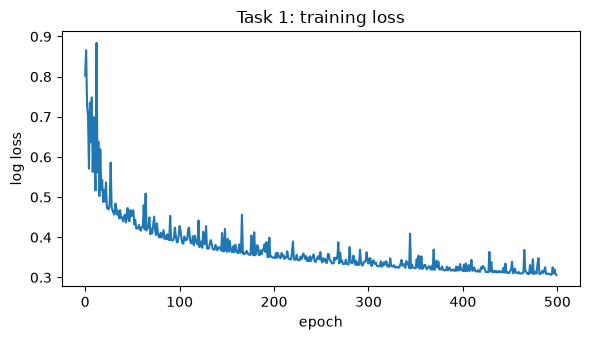

In [7]:
t0 = time.time()
w, b, losses = train(X_tr, y_tr, bs=512, epochs=500, lr=10.0)
print(f"trained in {time.time()-t0:.1f}s | final loss {losses[-1]:.4f}")

plt.figure(figsize=(6, 3.5))
plt.plot(losses)
plt.xlabel("epoch"); plt.ylabel("log loss"); plt.title("Task 1: training loss")
plt.tight_layout(); plt.show()

In [8]:
val_pred = predict(X_val)
print(f"scratch LR  | val macro F1 = {macro_f1(y_val, val_pred):.4f} "
      f"| accuracy = {accuracy_score(y_val, val_pred):.4f}")

# Benchmark only — NOT used for any submitted predictions.
from sklearn.linear_model import LogisticRegression
sk_lr = LogisticRegression(max_iter=2000, random_state=SEED).fit(X_tr, y_tr)
sk_pred = sk_lr.predict(X_val)
print(f"sklearn LR  | val macro F1 = {macro_f1(y_val, sk_pred):.4f} "
      f"| accuracy = {accuracy_score(y_val, sk_pred):.4f}")

scratch LR  | val macro F1 = 0.7318 | accuracy = 0.7540


sklearn LR  | val macro F1 = 0.7061 | accuracy = 0.7505


In [9]:
# Retrain on the full 20K labelled rows, then predict the test set.
w, b, _ = train(X_train, y_train, bs=512, epochs=500, lr=10.0)
save_predictions(test_ids, predict(X_test), "LogReg_Prediction.csv")

saved LogReg_Prediction.csv (6999 rows, positives=4657)


## Task 2 — PCA dimensionality reduction + KNN

PCA (sklearn allowed here) is fitted on the **train set only** (it never sees test
data) and used to transform train and test, for k ∈ {2000, 1000, 500, 100} components.
A `KNeighborsClassifier(n_neighbors=2)` is trained on each reduced train set. The four
test-set prediction files are submitted to Kaggle to obtain the Macro F1 scores for
the report; we also report validation-split Macro F1 here for analysis.

PCA(2000) fitted in 4.2s


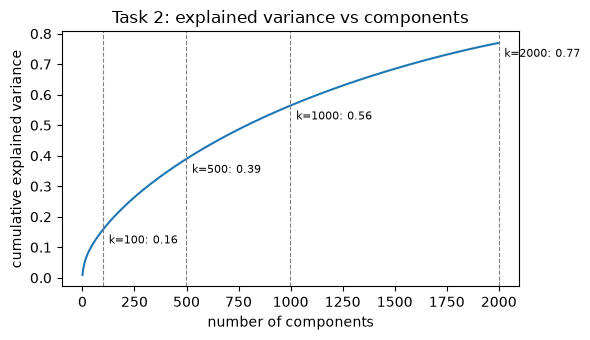

In [10]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

# Fit the largest PCA once to inspect how much variance each dimension keeps.
t0 = time.time()
pca_full = PCA(n_components=2000, svd_solver="randomized", random_state=SEED)
pca_full.fit(X_train)
print(f"PCA(2000) fitted in {time.time()-t0:.1f}s")

cum = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(6, 3.5))
plt.plot(cum)
for k in [100, 500, 1000, 2000]:
    plt.axvline(k - 1, ls="--", lw=0.8, color="grey")
    plt.annotate(f"k={k}: {cum[k-1]:.2f}", (k, cum[k - 1]), fontsize=8,
                 textcoords="offset points", xytext=(4, -10))
plt.xlabel("number of components"); plt.ylabel("cumulative explained variance")
plt.title("Task 2: explained variance vs components")
plt.tight_layout(); plt.show()

In [11]:
pca_rows = []
for k in [2000, 1000, 500, 100]:
    t0 = time.time()
    pca = PCA(n_components=k, svd_solver="randomized", random_state=SEED)
    Xtrain_k = pca.fit_transform(X_train)          # fit on train only
    Xtest_k = pca.transform(X_test)

    # Validation estimate: KNN on the 90% split, scored on the held-out 10%.
    knn_val = KNeighborsClassifier(n_neighbors=2, n_jobs=-1)
    knn_val.fit(Xtrain_k[tr_idx], y_tr)
    val_f1 = macro_f1(y_val, knn_val.predict(Xtrain_k[val_idx]))

    # Kaggle predictions: KNN trained on all 20K reduced rows.
    knn = KNeighborsClassifier(n_neighbors=2, n_jobs=-1)
    knn.fit(Xtrain_k, y_train)
    save_predictions(test_ids, knn.predict(Xtest_k), PRED_DIR / f"PCA_{k}.csv")

    pca_rows.append({"components": k, "explained_var": round(float(cum[k - 1]), 3),
                     "val_macro_f1": round(val_f1, 4),
                     "seconds": round(time.time() - t0, 1)})

pca_results = pd.DataFrame(pca_rows)
pca_results

saved predictions/PCA_2000.csv (6999 rows, positives=413)


saved predictions/PCA_1000.csv (6999 rows, positives=1237)


saved predictions/PCA_500.csv (6999 rows, positives=2580)


saved predictions/PCA_100.csv (6999 rows, positives=3814)


,components,explained_var,val_macro_f1,seconds
0,2000,0.770,0.4252,5.3
1,1000,0.564,0.5165,2.5
2,500,0.390,0.5960,1.2
3,100,0.158,0.6525,0.5


### Analysis

Kaggle test-set Macro F1 (public leaderboard) for the four submissions:

| components | explained variance | validation macro F1 | Kaggle public macro F1 |
|---|---|---|---|
| 2000 | 0.77 | 0.4252 | 0.41495 |
| 1000 | 0.56 | 0.5165 | 0.55923 |
| 500 | 0.39 | 0.5960 | 0.66373 |
| 100 | 0.16 | 0.6525 | **0.67793** |

Key observations:
- **Fewer components perform better**, even though they retain less variance. With
  `n_neighbors=2`, KNN relies on the nearest one or two points being truly similar;
  in high-dimensional space, pairwise distances concentrate (curse of dimensionality)
  and nearest-neighbour distinctions become meaningless. Cutting to 100 components
  keeps the dominant topical/stylistic directions while discarding thousands of noisy
  directions that corrupt the distance metric.
- Explained variance is spread thin (2000 components only reach 77%): TF-IDF matrices
  are sparse and high-dimensional, so no small subspace captures everything — yet the
  classification signal evidently lives in the first ~100 directions.
- `n_neighbors=2` is deliberately small and noise-sensitive: with a tie between one
  vote each, sklearn falls back to distance order, making the metric quality matter
  even more.
- The validation and Kaggle scores agree on the ranking (Spearman-perfect), which
  validates the 10% holdout as a cheap proxy for the leaderboard.

## Task 3 — Model race

We compare multiple classical ML models (no deep learning). Each subsection lists the
model and the key hyperparameters explored. Protocol: tune/fit on the 90% split
(`X_tr`), compare on the 10% validation split, and refit the winner on all 20K rows
for the final Kaggle submission. Tuning uses `f1_macro` scoring. The dataset is
imbalanced (62.5% machine), so `class_weight` is included in the linear-model grids.

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import lightgbm as lgb

race = {}   # name -> {"model", "params", "val_f1", "seconds", "kind"}

def evaluate(name, model, params_note, kind="feat"):
    """Fit on the 90% split, score on validation, save test predictions.

    kind="feat" uses the provided 5000 TF-IDF features; kind="text" uses raw text.
    """
    fit_X, val_X, test_X = ((X_tr, X_val, X_test) if kind == "feat" else
                            (train_text["text"].iloc[tr_idx],
                             train_text["text"].iloc[val_idx],
                             test_text["text"]))
    t0 = time.time()
    model.fit(fit_X, y_tr)
    val_f1 = macro_f1(y_val, model.predict(val_X))
    race[name] = {"model": model, "params": params_note, "val_f1": val_f1,
                  "seconds": round(time.time() - t0, 1), "kind": kind}
    save_predictions(test_ids, model.predict(test_X), PRED_DIR / f"task3_{name}.csv")
    print(f"{name}: val macro F1 = {val_f1:.4f}")

### Model 1 — Linear SVM (`LinearSVC`)
Linear SVMs are typically the strongest simple model on TF-IDF text features.
Key hyperparameters: `C` (inverse regularisation strength), `class_weight`.

In [13]:
grid = GridSearchCV(LinearSVC(random_state=SEED),
                    {"C": [0.01, 0.1, 0.5, 1.0, 5.0],
                     "class_weight": [None, "balanced"]},
                    scoring="f1_macro", cv=3, n_jobs=-1)
grid.fit(X_tr, y_tr)
print("best params:", grid.best_params_, f"| cv f1_macro = {grid.best_score_:.4f}")
evaluate("linearsvc", grid.best_estimator_, str(grid.best_params_))

best params: {'C': 0.5, 'class_weight': 'balanced'} | cv f1_macro = 0.7273


saved predictions/task3_linearsvc.csv (6999 rows, positives=4481)
linearsvc: val macro F1 = 0.7364


### Model 2 — Logistic Regression (sklearn, tuned)
Allowed here since Task 1's from-scratch requirement applies only to Task 1.
Key hyperparameters: `C`, `class_weight`.

In [14]:
grid = GridSearchCV(LogisticRegression(max_iter=3000, random_state=SEED),
                    {"C": [0.1, 1.0, 5.0, 10.0, 50.0],
                     "class_weight": [None, "balanced"]},
                    scoring="f1_macro", cv=3, n_jobs=-1)
grid.fit(X_tr, y_tr)
print("best params:", grid.best_params_, f"| cv f1_macro = {grid.best_score_:.4f}")
evaluate("logreg", grid.best_estimator_, str(grid.best_params_))

best params: {'C': 5.0, 'class_weight': 'balanced'} | cv f1_macro = 0.7276
saved predictions/task3_logreg.csv (6999 rows, positives=4574)
logreg: val macro F1 = 0.7359


### Model 3 — Complement Naive Bayes
A fast probabilistic baseline designed for TF-IDF-style features on imbalanced data
(requires non-negative inputs). Key hyperparameter: smoothing `alpha`.

In [15]:
grid = GridSearchCV(ComplementNB(), {"alpha": [0.01, 0.1, 0.5, 1.0]},
                    scoring="f1_macro", cv=3, n_jobs=-1)
grid.fit(X_tr, y_tr)
print("best params:", grid.best_params_, f"| cv f1_macro = {grid.best_score_:.4f}")
evaluate("complementnb", grid.best_estimator_, str(grid.best_params_))

best params: {'alpha': 0.01} | cv f1_macro = 0.6540


saved predictions/task3_complementnb.csv (6999 rows, positives=4856)
complementnb: val macro F1 = 0.6486


### Model 4 — Random Forest
Bagged decision trees; robust but can struggle with very high-dimensional sparse
features. Key hyperparameters: `n_estimators`, `max_features`.

In [16]:
rf = RandomForestClassifier(n_estimators=500, max_features="sqrt",
                            n_jobs=-1, random_state=SEED)
evaluate("randomforest", rf, "n_estimators=500, max_features=sqrt")

saved predictions/task3_randomforest.csv (6999 rows, positives=6212)
randomforest: val macro F1 = 0.6986


### Model 5 — XGBoost
Gradient-boosted trees (hist method). Key hyperparameters: `n_estimators`,
`learning_rate`, `max_depth`, `subsample`, `colsample_bytree`.

In [17]:
xgb_clf = xgb.XGBClassifier(n_estimators=800, learning_rate=0.1, max_depth=6,
                            subsample=0.8, colsample_bytree=0.8,
                            tree_method="hist", eval_metric="logloss",
                            n_jobs=-1, random_state=SEED)
evaluate("xgboost", xgb_clf, "n_estimators=800, lr=0.1, max_depth=6, subsample=0.8")

saved predictions/task3_xgboost.csv (6999 rows, positives=5599)
xgboost: val macro F1 = 0.7399


### Model 6 — LightGBM
Faster gradient boosting with leaf-wise growth. Key hyperparameters: `n_estimators`,
`learning_rate`, `num_leaves`.

In [18]:
lgb_clf = lgb.LGBMClassifier(n_estimators=800, learning_rate=0.1, num_leaves=63,
                             subsample=0.8, colsample_bytree=0.8,
                             n_jobs=-1, random_state=SEED, verbose=-1)
evaluate("lightgbm", lgb_clf, "n_estimators=800, lr=0.1, num_leaves=63, subsample=0.8")

/Users/nathanielneo/Desktop/ColdStart/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nathanielneo/Desktop/ColdStart/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


saved predictions/task3_lightgbm.csv (6999 rows, positives=5285)
lightgbm: val macro F1 = 0.7513


### Model 7 — Custom TF-IDF on the raw text + Linear SVM
The provided 5000 features cap the vocabulary. Since the competition also provides
the **raw text**, we build our own richer representation — word 1–2-grams plus
character 3–5-grams (character n-grams are strong for authorship/style detection) —
and feed it to a linear SVM. Still classical ML, no deep learning.
We vectorise once and sweep the SVM's `C` and `class_weight` on the validation split
(the dataset is 62.5/37.5 imbalanced, and macro F1 weighs both classes equally, so
`class_weight="balanced"` is worth testing). Variants we also tried that did **not**
beat this model: LogisticRegression on the same text features (0.8207), stacking the
provided 5000 TF-IDF features onto ours (0.8160), and a calibrated-SVC + LR soft vote
(0.8189).

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion, make_pipeline

text_union = FeatureUnion([
    ("word", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2,
                             sublinear_tf=True, max_features=300_000)),
])
t0 = time.time()
T_tr = text_union.fit_transform(train_text["text"].iloc[tr_idx])
T_val = text_union.transform(train_text["text"].iloc[val_idx])
print(f"vectorised: {T_tr.shape[1]} features in {time.time()-t0:.0f}s")

best_params, best_f1 = None, -1.0
for C in [0.25, 0.5, 1.0, 2.0]:
    for cw in [None, "balanced"]:
        f1 = macro_f1(y_val, LinearSVC(C=C, class_weight=cw, random_state=SEED)
                      .fit(T_tr, y_tr).predict(T_val))
        print(f"C={C}, class_weight={cw}: val macro F1 = {f1:.4f}")
        if f1 > best_f1:
            best_params, best_f1 = {"C": C, "class_weight": cw}, f1

text_pipe = make_pipeline(text_union,
                          LinearSVC(random_state=SEED, **best_params))
evaluate("text_tfidf_svc", text_pipe,
         f"word 1-2gram + char_wb 3-5gram TF-IDF, LinearSVC {best_params}",
         kind="text")

vectorised: 639528 features in 16s


C=0.25, class_weight=None: val macro F1 = 0.8190


C=0.25, class_weight=balanced: val macro F1 = 0.8229


C=0.5, class_weight=None: val macro F1 = 0.8207


C=0.5, class_weight=balanced: val macro F1 = 0.8214


C=1.0, class_weight=None: val macro F1 = 0.8173


C=1.0, class_weight=balanced: val macro F1 = 0.8208


C=2.0, class_weight=None: val macro F1 = 0.8168


C=2.0, class_weight=balanced: val macro F1 = 0.8141


saved predictions/task3_text_tfidf_svc.csv (6999 rows, positives=4727)
text_tfidf_svc: val macro F1 = 0.8229


### Model 8 — Soft-voting ensemble
Combines strong diverse feature-based models by averaging predicted probabilities.
LinearSVC has no `predict_proba`, so it is wrapped in `CalibratedClassifierCV`.

In [20]:
svc_params = {k: v for k, v in race["linearsvc"]["model"].get_params().items()
              if k in ("C", "class_weight")}
ensemble = VotingClassifier(
    estimators=[("svc", CalibratedClassifierCV(
                     LinearSVC(random_state=SEED, **svc_params), cv=3)),
                ("lr", LogisticRegression(max_iter=3000, random_state=SEED,
                                          **{k: v for k, v in race["logreg"]["model"]
                                             .get_params().items()
                                             if k in ("C", "class_weight")})),
                ("lgb", lgb.LGBMClassifier(**race["lightgbm"]["model"].get_params()))],
    voting="soft", n_jobs=-1)
evaluate("ensemble_soft", ensemble, "soft vote: calibrated LinearSVC + LR + LightGBM")

/Users/nathanielneo/Desktop/ColdStart/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/nathanielneo/Desktop/ColdStart/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


saved predictions/task3_ensemble_soft.csv (6999 rows, positives=5143)
ensemble_soft: val macro F1 = 0.7578


### Results summary

In [21]:
summary = (pd.DataFrame([{"model": k, "params": v["params"], "input": v["kind"],
                          "val_macro_f1": round(v["val_f1"], 4),
                          "fit_seconds": v["seconds"]}
                         for k, v in race.items()])
           .sort_values("val_macro_f1", ascending=False)
           .reset_index(drop=True))
summary

,model,params,input,val_macro_f1,fit_seconds
0,text_tfidf_svc,"word 1-2gram + char_wb 3-5gram TF-IDF, LinearS...",text,0.8229,17.0
1,ensemble_soft,soft vote: calibrated LinearSVC + LR + LightGBM,feat,0.7578,21.8
2,lightgbm,"n_estimators=800, lr=0.1, num_leaves=63, subsa...",feat,0.7513,21.8
3,xgboost,"n_estimators=800, lr=0.1, max_depth=6, subsamp...",feat,0.7399,31.2
4,linearsvc,"{'C': 0.5, 'class_weight': 'balanced'}",feat,0.7364,0.2
5,logreg,"{'C': 5.0, 'class_weight': 'balanced'}",feat,0.7359,0.1
6,randomforest,"n_estimators=500, max_features=sqrt",feat,0.6986,17.6
7,complementnb,{'alpha': 0.01},feat,0.6486,0.1


In [22]:
# Refit the winner on all 20K labelled rows for the final submission.
best_name = summary.iloc[0]["model"]
best = race[best_name]
print(f"Best model on validation: {best_name} (macro F1 = {best['val_f1']:.4f})")

if best["kind"] == "feat":
    best["model"].fit(X_train, y_train)
    final_pred = best["model"].predict(X_test)
else:
    best["model"].fit(train_text["text"], y_train)
    final_pred = best["model"].predict(test_text["text"])

save_predictions(test_ids, final_pred, PRED_DIR / "Task3_Final_Prediction.csv")

Best model on validation: text_tfidf_svc (macro F1 = 0.8229)


saved predictions/Task3_Final_Prediction.csv (6999 rows, positives=4688)


**Next steps for the race:** submit the per-model CSVs in `predictions/` to Kaggle,
record public-leaderboard Macro F1 next to the validation scores above, and iterate on
the hyperparameters of whichever model generalises best.